#  RF-Sentinel — Layer 3: Model Training and Evaluation
> **Models:** XGBoost + 1D-CNN + Ensemble  
> **Datasets:** CMAPSS FD001 (binary) · AI4I 2020 (6-class)

In [1]:
import sys
import warnings
import time
warnings.filterwarnings("ignore")
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

ROOT       = Path("..")
MODELS_DIR = ROOT / "outputs" / "models"


def show_plot(path, figsize=(14, 5)):
    path = Path(path)
    if not path.exists():
        print(f"  [missing] {path}")
        return
    img = mpimg.imread(str(path))
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


print("Setup complete")

Setup complete


## 1️ XGBoost on CMAPSS FD001 — Binary Classification
> **Task:** pass vs sensor_degradation using 14 sensor features

In [2]:
from layer1_data_ingestion.loaders import load_cmapss
from layer1_data_ingestion.preprocessor import preprocess_cmapss
from layer1_data_ingestion.config import CMAPSS_USEFUL_SENSORS
from layer3_models.xgb_classifier import RFSentinelXGB

data      = load_cmapss("FD001")
processed = preprocess_cmapss(data)

xgb = RFSentinelXGB()
xgb.build()
metrics = xgb.train(
    processed["X_train"], processed["y_train"],
    processed["X_val"],   processed["y_val"],
    feature_names=CMAPSS_USEFUL_SENSORS,
)
print(f"Train F1 : {metrics['train_score']:.4f}")
print(f"Val F1   : {metrics['val_score']:.4f}")
print(f"Classes  : {list(metrics['classes'])}")

2026-05-18 21:52:09.711 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD001] engines=100 | train_rows=20,631 | fail_rate=15.0% | features=14 | test=yes
2026-05-18 21:52:09.872 | INFO     | layer1_data_ingestion.preprocessor:preprocess_cmapss:155 - [C-MAPSS | FD001] train=(16504, 14) | val=(4127, 14) | test=yes
2026-05-18 21:52:09.876 | INFO     | layer3_models.xgb_classifier:build:112 - [xgb_classifier] Built XGBClassifier — params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0.3, 'reg_lambda': 2.0, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0}
2026-05-18 21:52:09.878 | INFO     | layer3_models.base_model:log_training_start:287 - ────────────────────────────────────────────────────
2026-05-18 21:52:09.881 | INFO     | layer3_models.base_model:log_training_start:288 -  

Train F1 : 0.9734
Val F1   : 0.9521
Classes  : [0, 1]


  [missing] ..\outputs\models\xgboost\xgb_classifier_training_curves.png
  [missing] ..\outputs\models\xgboost\xgb_classifier_feature_importance.png


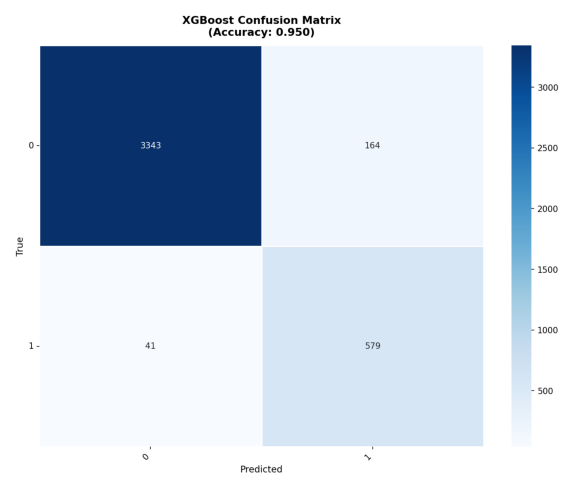

In [3]:
for name in [
    "xgb_classifier_training_curves.png",
    "xgb_classifier_feature_importance.png",
    "xgb_classifier_confusion_matrix.png",
]:
    show_plot(MODELS_DIR / "xgboost" / name)

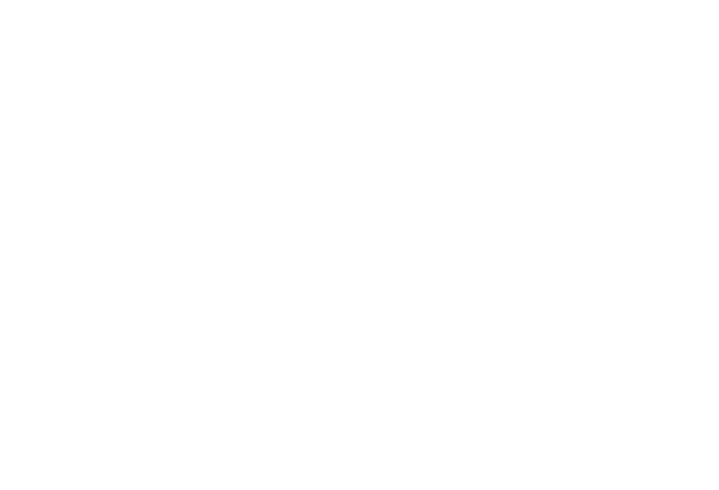

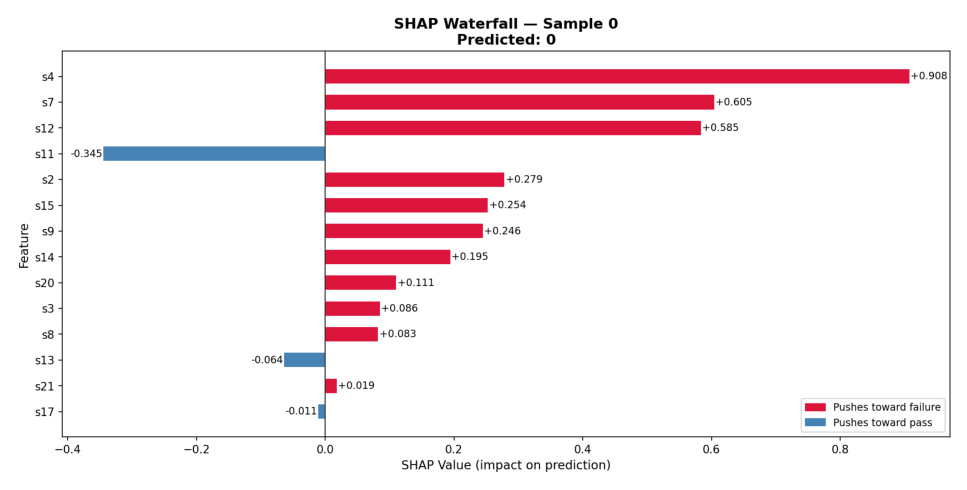

Red bars  = features pushing TOWARD failure
Blue bars = features pushing TOWARD pass


In [4]:
for name in [
    "xgb_shap_summary.png",
    "xgb_classifier_shap_waterfall_0.png",
]:
    show_plot(MODELS_DIR / "xgboost" / name)
print("Red bars  = features pushing TOWARD failure")
print("Blue bars = features pushing TOWARD pass")

## 2️ XGBoost on AI4I — 6-Class Failure Type Classification
> **Classes:** TWF · HDF · PWF · OSF · RNF · pass

In [5]:
from layer1_data_ingestion.loaders import load_ai4i
from layer1_data_ingestion.preprocessor import preprocess_ai4i
from layer1_data_ingestion.config import AI4I_FEATURE_COLS

ai4i = load_ai4i()
p2   = preprocess_ai4i(ai4i, target="multiclass")

xgb2 = RFSentinelXGB()
xgb2.model_name = "xgb_classifier_ai4i"
xgb2.build()
m2 = xgb2.train(
    p2["X_train"], p2["y_train"],
    p2["X_val"],   p2["y_val"],
    feature_names=AI4I_FEATURE_COLS,
)
print(f"Train F1 weighted : {m2['train_score']:.4f}")
print(f"Val F1 weighted   : {m2['val_score']:.4f}")
print(f"Classes           : {list(m2['classes'])}")

2026-05-18 21:52:34.849 | SUCCESS  | layer1_data_ingestion.loaders:load_ai4i:313 - [AI4I] samples=10,000 | features=6 | failures=339 (3.39%) | failure_types=6
2026-05-18 21:52:34.883 | DEBUG    | layer1_data_ingestion.preprocessor:build_tabular_pipeline:89 - [Pipeline] Built pipeline steps: ['imputer', 'variance', 'scaler', 'smote']
2026-05-18 21:52:35.008 | INFO     | layer1_data_ingestion.preprocessor:preprocess_ai4i:306 - [AI4I | target=multiclass] train_after_SMOTE=(46332, 6) | val=(2000, 6)
2026-05-18 21:52:35.010 | INFO     | layer3_models.xgb_classifier:build:112 - [xgb_classifier_ai4i] Built XGBClassifier — params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0.3, 'reg_lambda': 2.0, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0}
2026-05-18 21:52:35.018 | INFO     | layer3_models.base_mode

Train F1 weighted : 0.9917
Val F1 weighted   : 0.9477
Classes           : ['heat_dissipation_failure', 'overstrain_failure', 'pass', 'power_failure', 'random_failure', 'thermal_wear_failure']


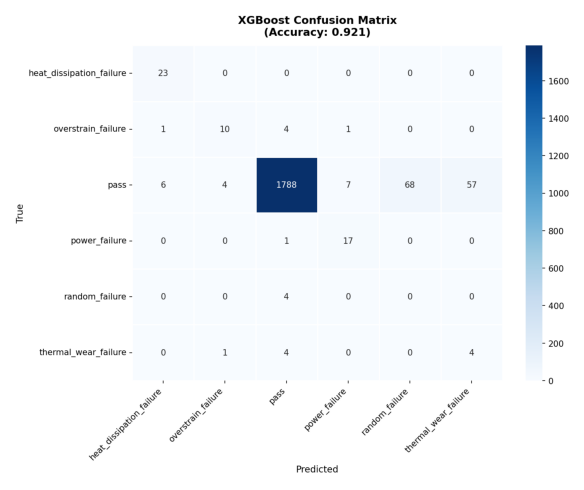

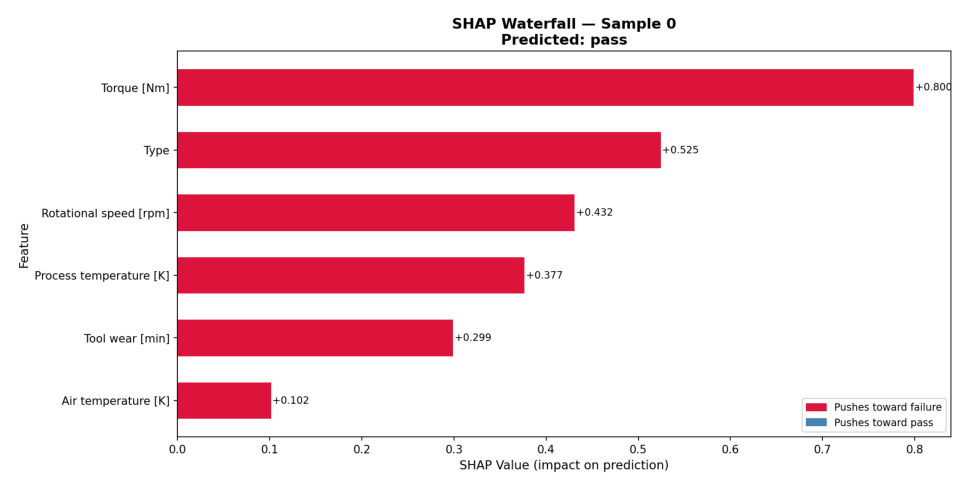

In [6]:
for name in [
    "xgb_classifier_ai4i_confusion_matrix.png",
    "xgb_classifier_ai4i_shap_waterfall_0.png",
]:
    show_plot(MODELS_DIR / "xgboost" / name)

## 3️ 1D-CNN on CMAPSS — Sliding Window Time-Series Classification
> **Input:** 14 sensors × 30 cycles per window  
> **Architecture:** 3 Conv1d blocks + GlobalAvgPool + FC

In [ ]:
from layer3_models.cnn1d_model import RFSentinelCNN1D

train_raw = data["train_raw"]
all_units = train_raw["unit_id"].unique()
np.random.seed(42)
np.random.shuffle(all_units)
n_train  = int(len(all_units) * 0.8)
train_df = train_raw[train_raw["unit_id"].isin(all_units[:n_train])]
val_df   = train_raw[train_raw["unit_id"].isin(all_units[n_train:])]

cnn = RFSentinelCNN1D()
cnn.build()
print("Training CNN — ~3 min on CPU...")
cm = cnn.train(train_df, None, val_df, None,
               n_epochs=30, batch_size=64)
print(f"Train Accuracy : {cm['train_score']:.4f}")
print(f"Val Accuracy   : {cm['val_score']:.4f}")
print(f"Training time  : {cm['training_time']:.1f}s")

2026-05-18 21:53:15.407 | INFO     | layer3_models.cnn1d_model:build:332 - [cnn1d_model] Built CNN1D — input=(14, 30) | n_classes=2 | params=47,010 | device=cpu
2026-05-18 21:53:16.089 | INFO     | layer3_models.cnn1d_model:plot_model_summary:488 - [cnn1d_model] Model summary saved → D:\RF Engineering\rf_sentinel\outputs\models\cnn1d\cnn1d_model_summary.png
2026-05-18 21:53:16.089 | INFO     | layer3_models.cnn1d_model:build:343 - [cnn1d_model] Architecture summary plot saved
2026-05-18 21:53:16.095 | INFO     | layer3_models.base_model:log_training_start:287 - ────────────────────────────────────────────────────
2026-05-18 21:53:16.098 | INFO     | layer3_models.base_model:log_training_start:288 -   Training cnn1d_model on CMAPSS (sliding windows)
2026-05-18 21:53:16.101 | INFO     | layer3_models.base_model:log_training_start:289 -   X shape : (16340, 28) | y shape: (16340,)
2026-05-18 21:53:16.104 | INFO     | layer3_models.base_model:log_training_start:290 -   Started : 2026-05-18 

Training CNN — ~3 min on CPU...


2026-05-18 21:53:16.511 | INFO     | layer3_models.cnn1d_model:__init__:166 - [CMAPSSWindowDataset] Created 14,020 windows (window=30, fail_rate=17.7%)
2026-05-18 21:53:16.622 | INFO     | layer3_models.cnn1d_model:__init__:166 - [CMAPSSWindowDataset] Created 3,711 windows (window=30, fail_rate=16.7%)
2026-05-18 21:53:31.579 | INFO     | layer3_models.cnn1d_model:train:601 -   Epoch   1/30 — train_loss=0.2689 train_acc=0.8846 | val_loss=6.5097 val_acc=0.1671
2026-05-18 21:54:45.546 | INFO     | layer3_models.cnn1d_model:train:601 -   Epoch   5/30 — train_loss=0.1840 train_acc=0.9223 | val_loss=4.0377 val_acc=0.1671
2026-05-18 21:55:41.379 | INFO     | layer3_models.cnn1d_model:train:601 -   Epoch  10/30 — train_loss=0.1748 train_acc=0.9248 | val_loss=0.1856 val_acc=0.9178
2026-05-18 21:56:41.688 | INFO     | layer3_models.cnn1d_model:train:601 -   Epoch  15/30 — train_loss=0.1626 train_acc=0.9321 | val_loss=0.2527 val_acc=0.8860


In [ ]:
for name in [
    "cnn1d_model_summary.png",
    "cnn1d_training_curves.png",
    "cnn1d_confusion_matrix.png",
]:
    show_plot(MODELS_DIR / "cnn1d" / name)

## 4️w Ensemble — Soft-Vote Combination
> **Weights:** 55% XGBoost + 45% CNN

In [ ]:
from layer3_models.ensemble import RFSentinelEnsemble

ensemble = RFSentinelEnsemble(xgb_weight=0.55, cnn_weight=0.45)
ensemble.build()
em = ensemble.train(
    processed["X_val"], processed["y_val"],
    train_df=train_df, val_df=val_df
)
print(f"XGBoost Val F1  : {em['xgb_val_f1']:.4f}")
print(f"CNN Val Accuracy: {em['cnn_val_acc']:.4f}")
print(f"Ensemble Val F1 : {em['ensemble_val_f1']:.4f}")

In [ ]:
show_plot(MODELS_DIR / "ensemble" / "ensemble_model_comparison.png")

##  Layer 3 Summary

| Model | Val Score | Type |
|-------|-----------|------|
| XGBoost CMAPSS | 0.9521 | F1 weighted |
| XGBoost AI4I | 0.9477 | F1 weighted |
| 1D-CNN CMAPSS | 0.8666 | Accuracy |
| Ensemble (55% XGB + 45% CNN) | 0.9466 | F1 weighted |

**Next → Layer 4: MLflow experiment tracking**